# FRB isotropy analysis

Stepwise executable notebook for the `frb_isotropy.py` pipeline. The notebook keeps the scientific workflow visible while treating the Python module as the source of truth for the analysis implementation and configuration.


## 1. Imports and run configuration

Choose one run configuration explicitly below. The four scientific combinations of Galactic masking and selection-function modeling are all supported; sensitivity analysis is only valid when `use_sel_func=True`.


In [1]:
%load_ext autoreload
%autoreload 2

import frb_isotropy as iso
import numpy as np

RUN_CONFIG = iso.AnalysisConfig(
    use_gal_mask=True,
    use_sel_func=True,
    run_sensitivity=False,
)

iso.apply_analysis_config(RUN_CONFIG)

SAVE_OUTPUTS = True
RUN_TOP_SURVEY_MAPS = False

print("\n==================================================")
print("FRB ISOTROPY PIPELINE")
print("==================================================")
print(f"RUN_TAG         = {iso.RUN_TAG}")
print(f"USE_GAL_MASK    = {iso.USE_GAL_MASK}")
print(f"USE_SEL_FUNC    = {iso.USE_SEL_FUNC}")
print(f"RUN_SENSITIVITY = {iso.RUN_SENSITIVITY}")
print(f"BIN_SIZE        = {iso.BIN_SIZE} deg")
print(f"N_JOBS          = {iso.N_JOBS}")
print("==================================================")



FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : True
USE_SEL_FUNC : True
GAL_CUT      : 20.0 deg
BIN_SIZE     : 10.0 deg
N_BINS       : 17
NSIDE_SF     : 64
SMOOTH_SIGMA : 3.0
N_MOCKS      : 1000
RUN_TAG      : mask_sf_nosens_bin10


FRB ISOTROPY PIPELINE
RUN_TAG         = mask_sf_nosens_bin10
USE_GAL_MASK    = True
USE_SEL_FUNC    = True
RUN_SENSITIVITY = False
BIN_SIZE        = 10.0 deg
N_JOBS          = 100


## 2. Load and mask the observed catalog


In [2]:
df_data = iso.apply_mask(
    iso.load_catalog(iso.ALL_FRB_PATH)
)

print(f"Masked catalog size: {len(df_data)}")


--- Catalog loaded ---
Objects: 4480

--- Galactic mask applied ---
gal_cut = ±20.0 deg
Remaining objects: 2732
Removed objects: 1748
Masked catalog size: 2732


## 3. Build and validate survey selection functions



--- Survey partitioning ---
Unique surveys: 19

Survey populations:
          CHIME | N=2555 |  93.52%
         FRBCAT | N=  77 |   2.82%
          CRAFT | N=  33 |   1.21%
         PARKES | N=  22 |   0.81%
          ALERT | N=  15 |   0.55%
       MeerTRAP | N=   8 |   0.29%
           FAST | N=   5 |   0.18%
     Pan-STARRS | N=   4 |   0.15%
          ATLAS | N=   3 |   0.11%
   VLA-realfast | N=   2 |   0.07%
     GaiaAlerts | N=   2 |   0.07%
         UTMOST | N=   2 |   0.07%
            ZTF | N=   1 |   0.04%
        Tianlai | N=   1 |   0.04%
         TRAPUM | N=   1 |   0.04%
     VLITE-Fast | N=   1 |   0.04%
          GBNCC | N=   1 |   0.04%
         MASTER | N=   1 |   0.04%
        ASAS-SN | N=   1 |   0.04%

--- Building selection functions ---
Unique surveys: 19
            ZTF | N=   1 | sigma= 8.0 deg | weight=0.0004
          CRAFT | N=  33 | sigma= 3.0 deg | weight=0.0121
       MeerTRAP | N=   8 | sigma= 8.0 deg | weight=0.0029
     Pan-STARRS | N=   4 | sigma= 8

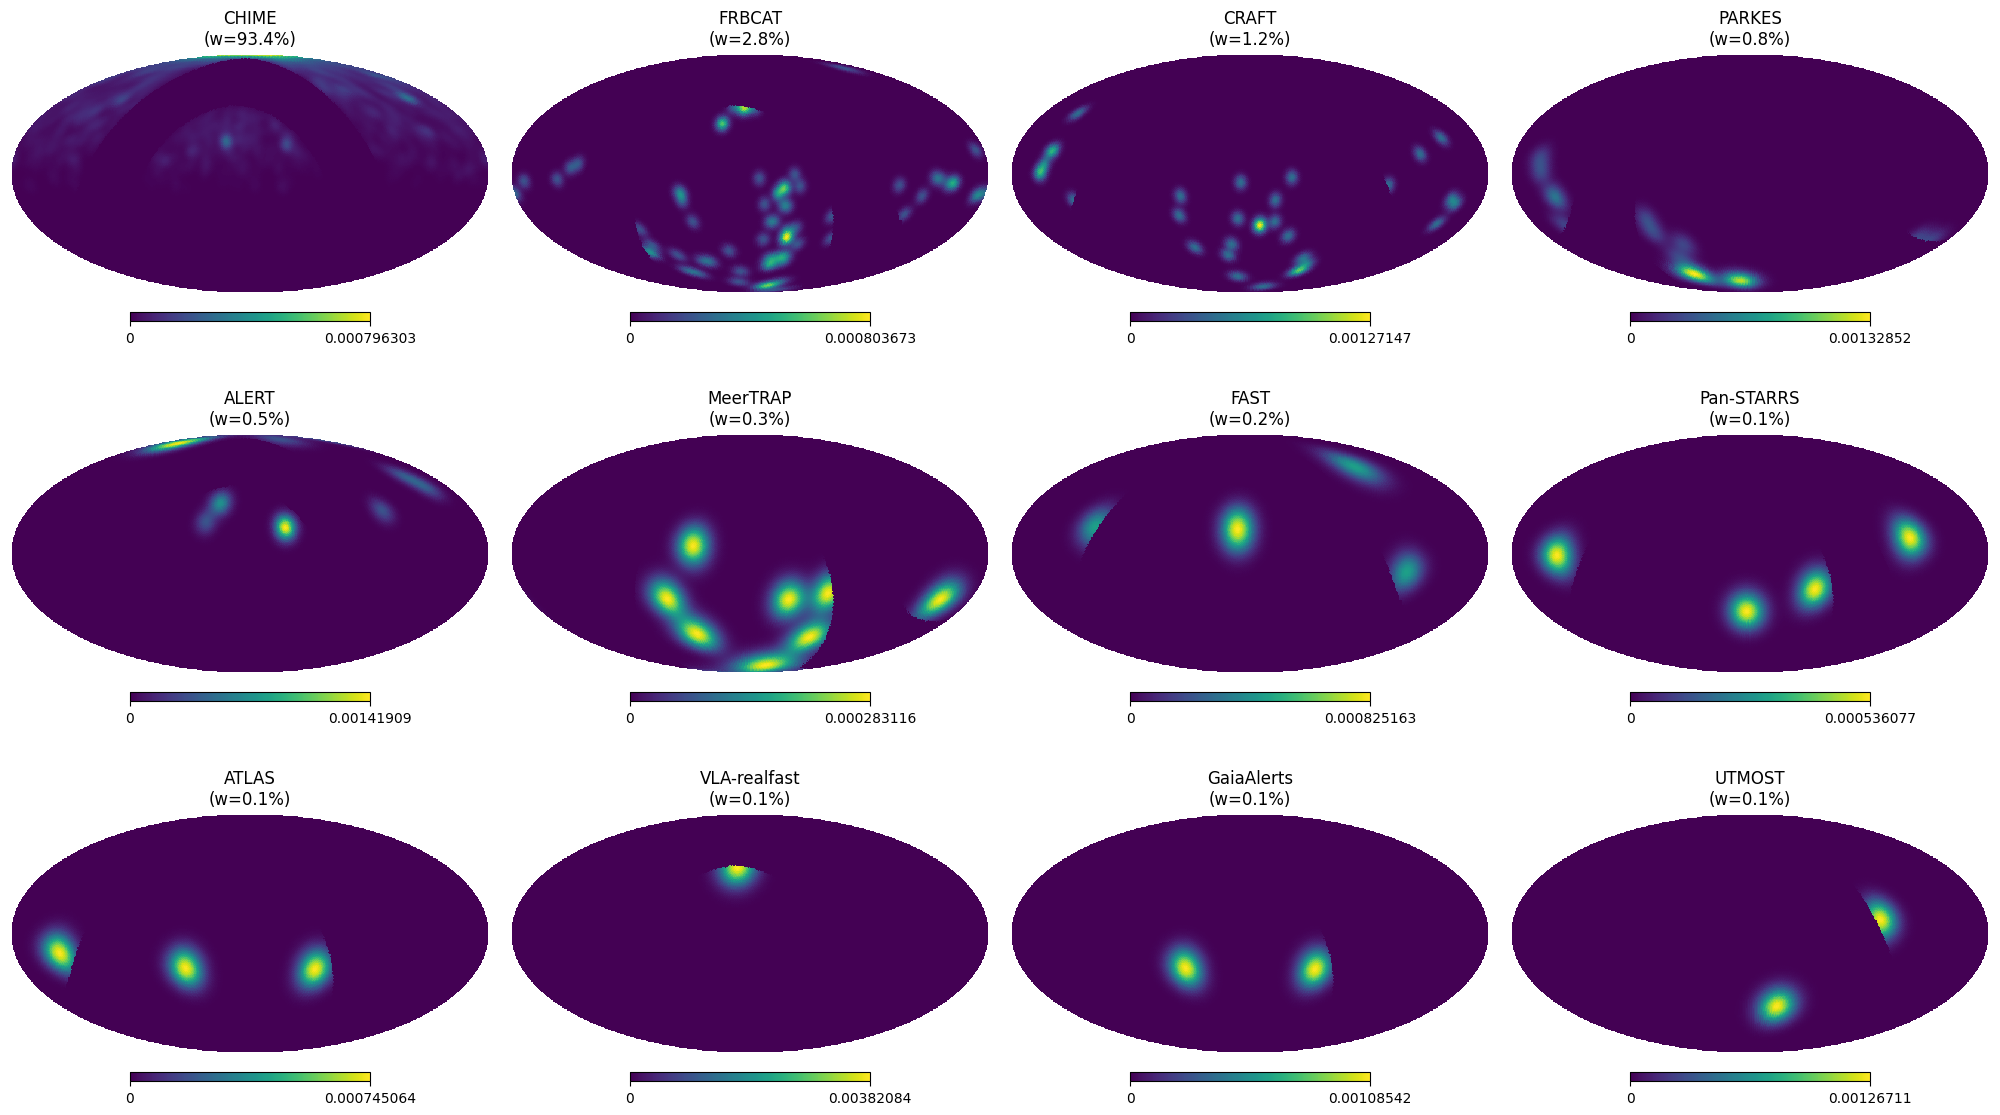

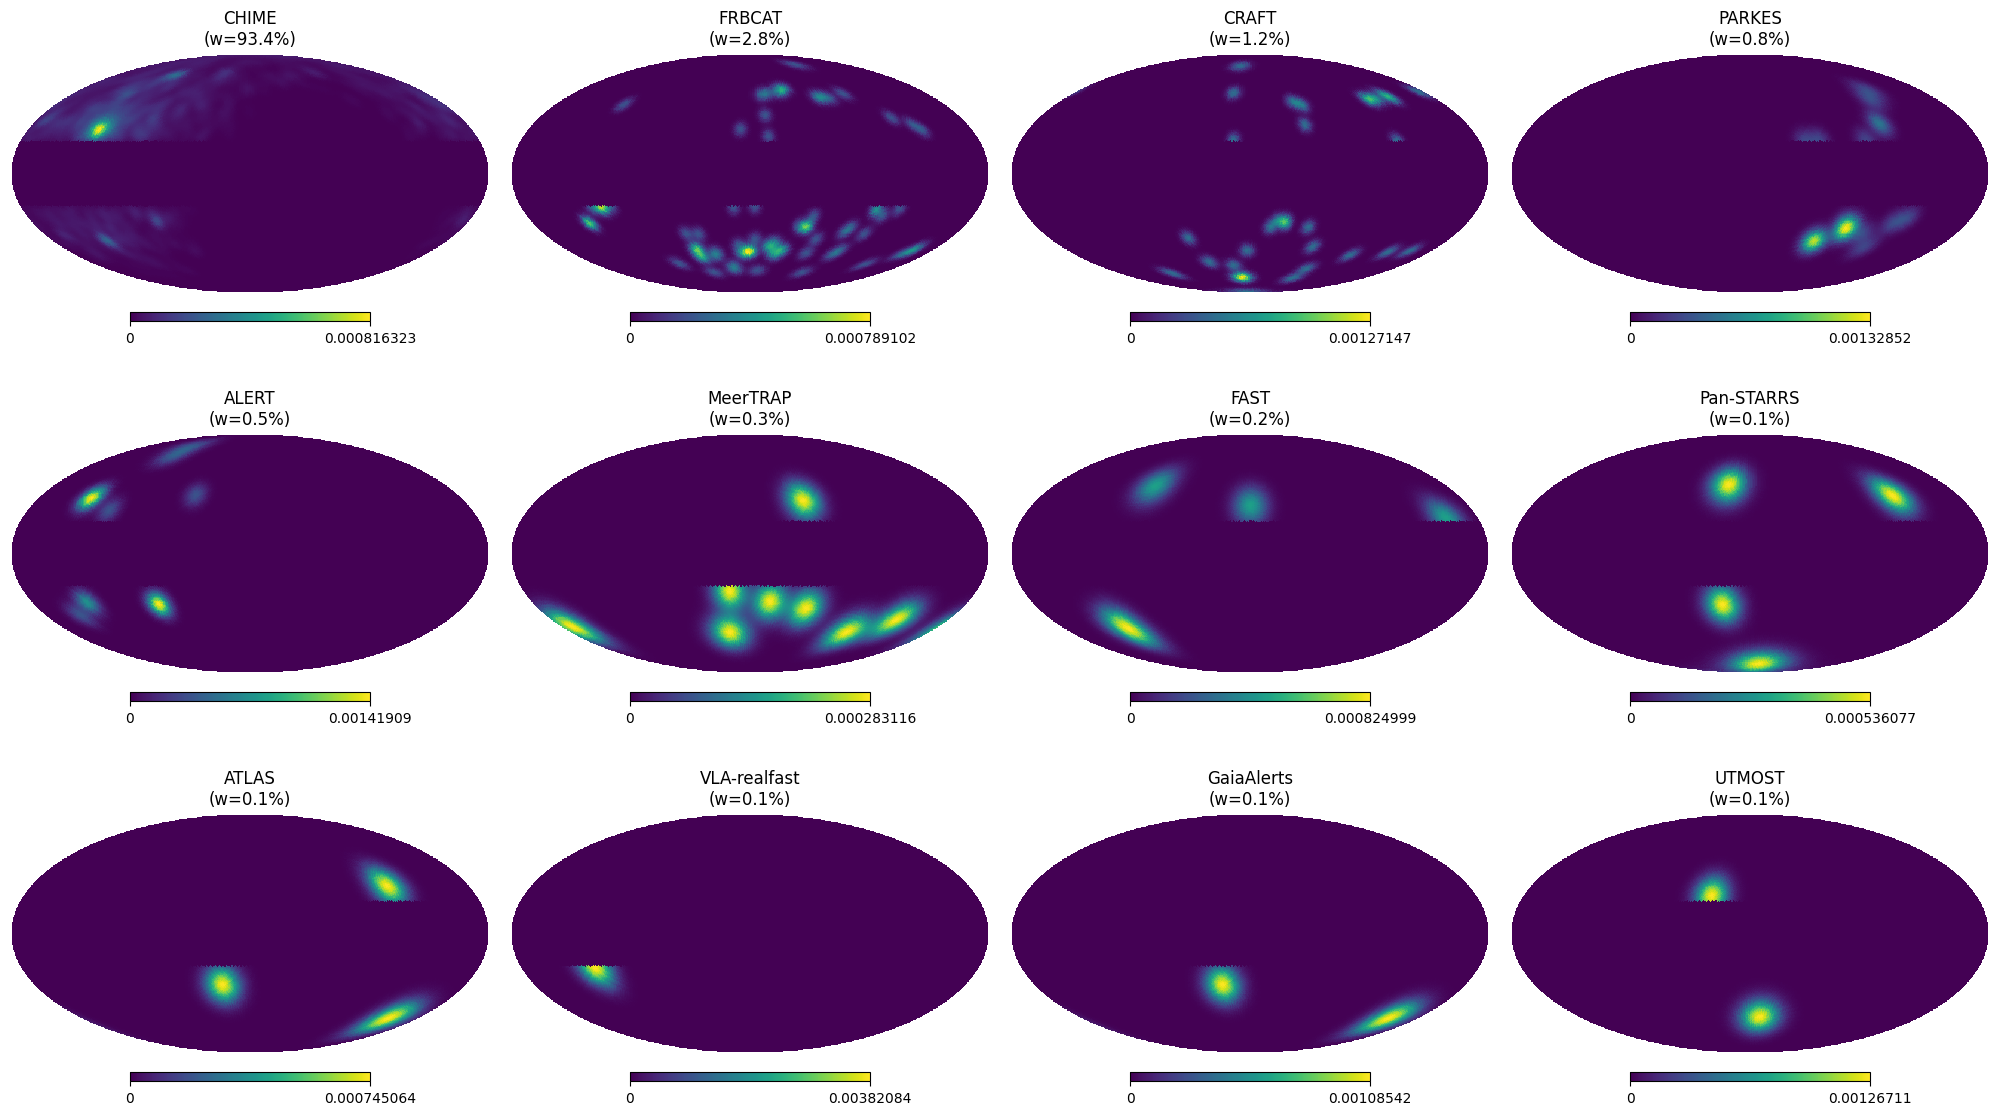


Selection-function maps saved:
  sf_validation_mask_sf_nosens_bin10_mask_sf_nosens_bin10_equatorial.png
  sf_validation_mask_sf_nosens_bin10_mask_sf_nosens_bin10_galactic.png


In [3]:
sf_dict, sf_cov_diag_dict, survey_weights, sf_nside = (
    iso.build_survey_selection_functions_improved(
        df_data,
        nside=iso.NSIDE_SF,
        smooth_sigma=iso.SMOOTH_SIGMA,
    )
)

sf_validation = None

if iso.USE_SEL_FUNC:
    validator = iso.SelectionFunctionValidator(
        sf_dict,
        survey_weights,
        sf_nside,
    )

    sf_validation = validator.check_coverage()

    validator.plot_sf(
        save_prefix=f"sf_validation_{iso.RUN_TAG}",
    )
else:
    print("Selection-function validation skipped because USE_SEL_FUNC=False.")

## 4. Survey diagnostics


In [4]:
corr_df, overlap_df = iso.analyze_intersurvey_correlations(df_data)


--- Survey partitioning ---
Unique surveys: 19

Survey populations:
          CHIME | N=2555 |  93.52%
         FRBCAT | N=  77 |   2.82%
          CRAFT | N=  33 |   1.21%
         PARKES | N=  22 |   0.81%
          ALERT | N=  15 |   0.55%
       MeerTRAP | N=   8 |   0.29%
           FAST | N=   5 |   0.18%
     Pan-STARRS | N=   4 |   0.15%
          ATLAS | N=   3 |   0.11%
   VLA-realfast | N=   2 |   0.07%
     GaiaAlerts | N=   2 |   0.07%
         UTMOST | N=   2 |   0.07%
            ZTF | N=   1 |   0.04%
        Tianlai | N=   1 |   0.04%
         TRAPUM | N=   1 |   0.04%
     VLITE-Fast | N=   1 |   0.04%
          GBNCC | N=   1 |   0.04%
         MASTER | N=   1 |   0.04%
        ASAS-SN | N=   1 |   0.04%

INTERSURVEY CORRELATION ANALYSIS

Unique surveys: 19
HEALPix nside: 32
Overlap radius: 5.0 deg

--- Spatial correlation summary ---
Mean survey correlation: 0.0097
Max survey correlation: 0.8165
Mean overlap fraction: 5.84%
Max overlap fraction: 100.00%

High overl

## 5. Observed correlation statistics


In [5]:
df_rand_obs = iso.generate_mixture_catalog_improved(
    n_observed=len(df_data) * iso.N_RAND_FACTOR,
    sf_dict=sf_dict,
    weights=survey_weights,
    nside=sf_nside,
    seed=2000,
    use_poisson=False,
)

theta, w_obs = iso.compute_2pacf(
    df_data,
    df_rand_obs,
)

abs_obs = iso.get_absolute_sum(theta, w_obs)

print("theta bins:", theta.shape)
print("w_obs:", w_obs.shape)
print("abs_obs:", abs_obs.shape)

theta bins: (17,)
w_obs: (17,)
abs_obs: (9,)


## 6. Observational uncertainty estimation



JACKKNIFE UNCERTAINTY ESTIMATION
RUN_TAG = mask_sf_nosens_bin10

--- Jackknife region assignment ---
NSIDE_JACKKNIFE = 4
Populated regions = 131

--- Jackknife region statistics ---
Objects per region:
min    = 1
median = 9.0
max    = 179


Jackknife regions:   0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]


FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : True
USE_SEL_FUNC : True
GAL_CUT      : 20.0 deg
BIN_SIZE     : 10.0 deg
N_BINS       : 17
NSIDE_SF     : 64
SMOOTH_SIGMA : 3.0
N_MOCKS      : 1000
RUN_TAG      : mask_sf_nosens_bin10


FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : True
USE_SEL_FUNC : True
GAL_CUT      : 20.0 deg
BIN_SIZE     : 10.0 deg
N_BINS       : 17
NSIDE_SF     : 64
SMOOTH_SIGMA : 3.0
N_MOCKS      : 1000
RUN_TAG      : mask_sf_nosens_bin10


FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : True
USE_SEL_FUNC : True
GAL_CUT      : 20.0 deg
BIN_SIZE     : 10.0 deg
N_BINS       : 17
NSIDE_SF     : 64
SMOOTH_SIGMA : 3.0
N_MOCKS      : 1000
RUN_TAG      : mask_sf_nosens_bin10


FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : True
USE_SEL_FUNC : True
GAL_CUT      : 20.0 deg
BIN_SIZE     : 10.0 deg
N_BINS       : 17
NSIDE_SF     : 64
SMOOTH_SIGMA : 3.0
N_MOCKS      : 1000
RUN_TAG      : mask_sf_nosens_bin10


FRB ISOTROPY PIPELINE CONFIGURATION
USE_GAL_MASK : 

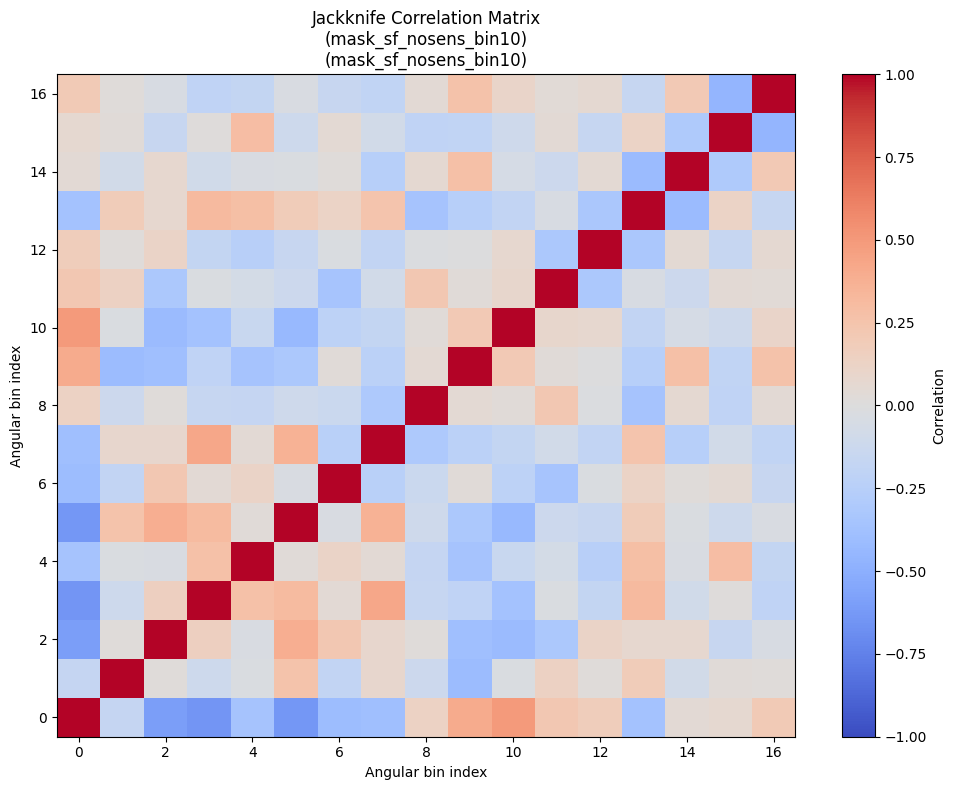


Saved correlation matrix:
  JK_correlation_matrix_mask_sf_nosens_bin10_mask_sf_nosens_bin10.png

BOOTSTRAP UNCERTAINTY ESTIMATION
RUN_TAG = mask_sf_nosens_bin10

Bootstrap realizations = 500

Generating fixed random catalog...
Random catalog size = 54640


Bootstrap realizations:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


--- Bootstrap summary ---
Median sigma[w(theta)] = 3.4121e-03
Median sigma[|<w>|] = 1.6739e-03
Max sigma[w(theta)] = 1.2082e-02
Max sigma[|<w>|] = 3.8994e-03

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0563
Median off-diagonal corr: -0.0381
95th percentile corr: 0.0653
Max off-diagonal corr: 0.1132


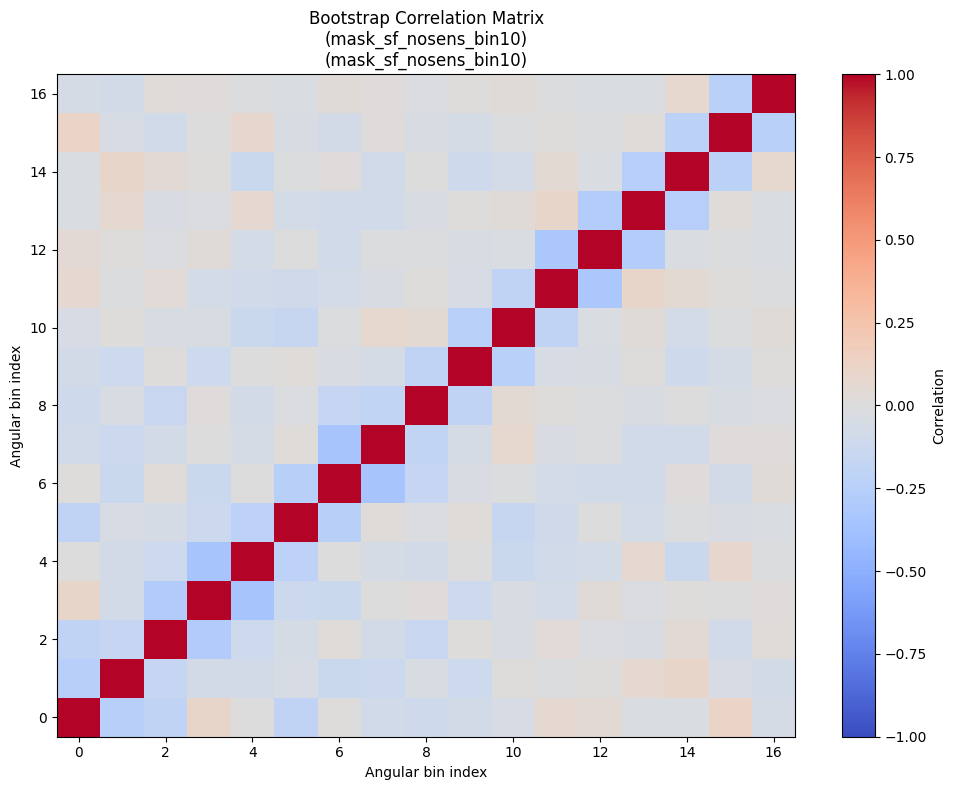


Saved correlation matrix:
  Bootstrap_correlation_matrix_mask_sf_nosens_bin10.png_mask_sf_nosens_bin10.png


In [6]:
jackknife = iso.run_jackknife_errors(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    nside_jackknife=iso.NSIDE_JACKKNIFE,
    min_regions=iso.MIN_JACKKNIFE_REGIONS,
    n_jobs=iso.N_JOBS,
)

bootstrap = iso.run_bootstrap_errors(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    n_bootstrap=iso.N_BOOTSTRAP,
    n_jobs=iso.N_JOBS,
)

## 7. Covariance diagnostics for resampling uncertainties



--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0528
Median off-diagonal corr: -0.0340
95th percentile corr: 0.2993
Max off-diagonal corr: 0.4954


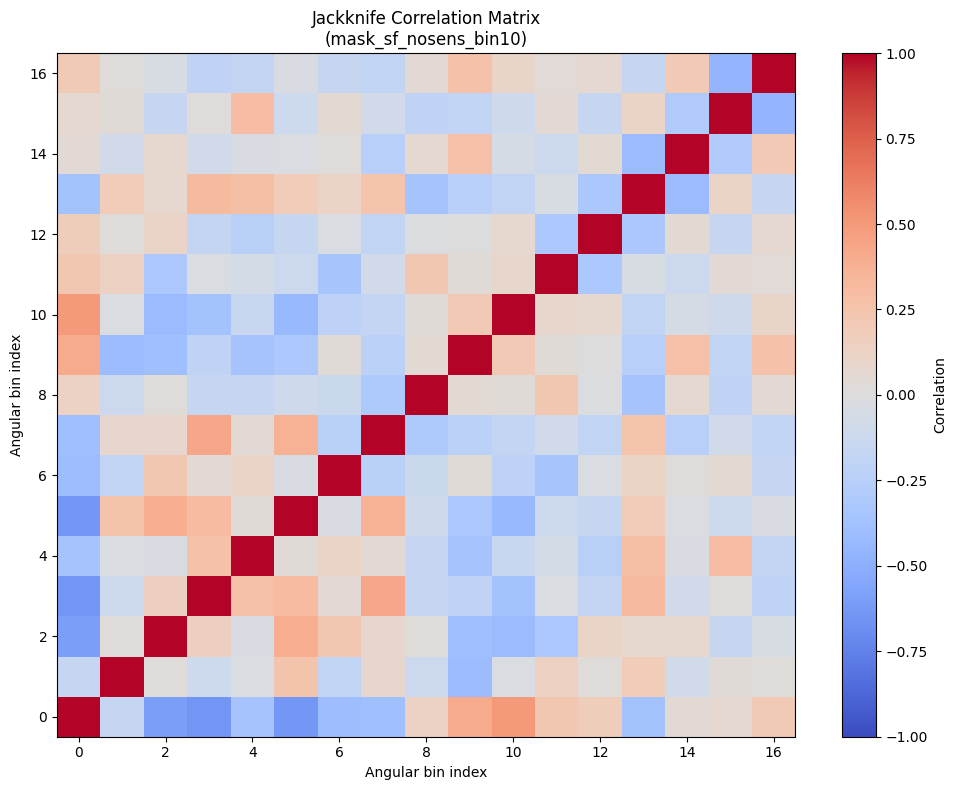


Saved correlation matrix:
  JK_correlation_matrix_mask_sf_nosens_bin10.png

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0563
Median off-diagonal corr: -0.0381
95th percentile corr: 0.0653
Max off-diagonal corr: 0.1132


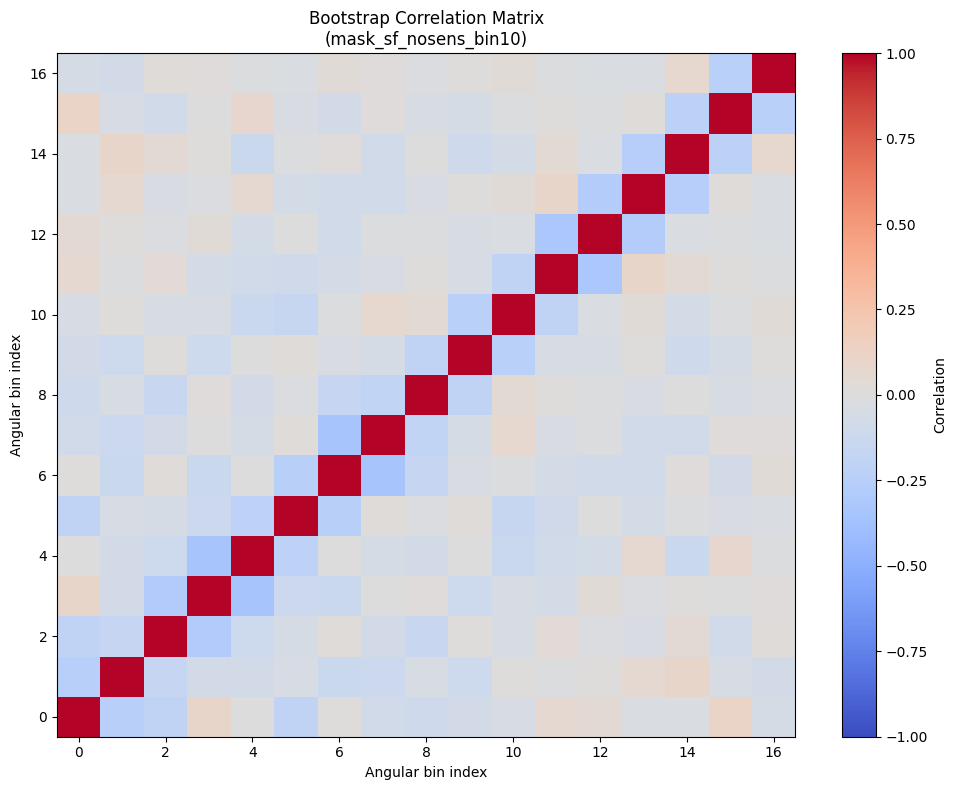


Saved correlation matrix:
  Bootstrap_correlation_matrix_mask_sf_nosens_bin10.png


In [7]:
iso.plot_covariance_correlation_matrix(
    jackknife.w_cov,
    title="Jackknife Correlation Matrix",
    output="JK_correlation_matrix",
)

iso.plot_covariance_correlation_matrix(
    bootstrap.w_cov,
    title="Bootstrap Correlation Matrix",
    output="Bootstrap_correlation_matrix",
)

## 8. H0 mock ensemble


In [8]:
all_w_h0, all_abs_h0 = iso.run_ensemble_mocks(
    df_data,
    sf_dict,
    sf_cov_diag_dict,
    survey_weights,
    sf_nside,
    n_ensemble=iso.N_ENSEMBLE,
    n_mocks_per=iso.N_MOCKS_PER_ENSEMBLE,
    perturbation_scale=iso.PERTURBATION_SCALE,
    n_rand_factor=iso.N_RAND_FACTOR,
    n_jobs=iso.N_JOBS,
)

print("all_w_h0:", all_w_h0.shape)
print("all_abs_h0:", all_abs_h0.shape)


--- Generating H0 ensemble mocks (with selection functions) ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generated mocks:
  w(theta): (1000, 17)
  |<w>|: (1000, 9)
all_w_h0: (1000, 17)
all_abs_h0: (1000, 9)


## 9. Statistical inference



GLOBAL ISOTROPY INFERENCE
RUN_TAG = mask_sf_nosens_bin10
USE_GAL_MASK = True
USE_SEL_FUNC = True

Max |H0 mean| = 7.3683e-04

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0557
Median off-diagonal corr: -0.0552
95th percentile corr: 0.0246
Max off-diagonal corr: 0.0539


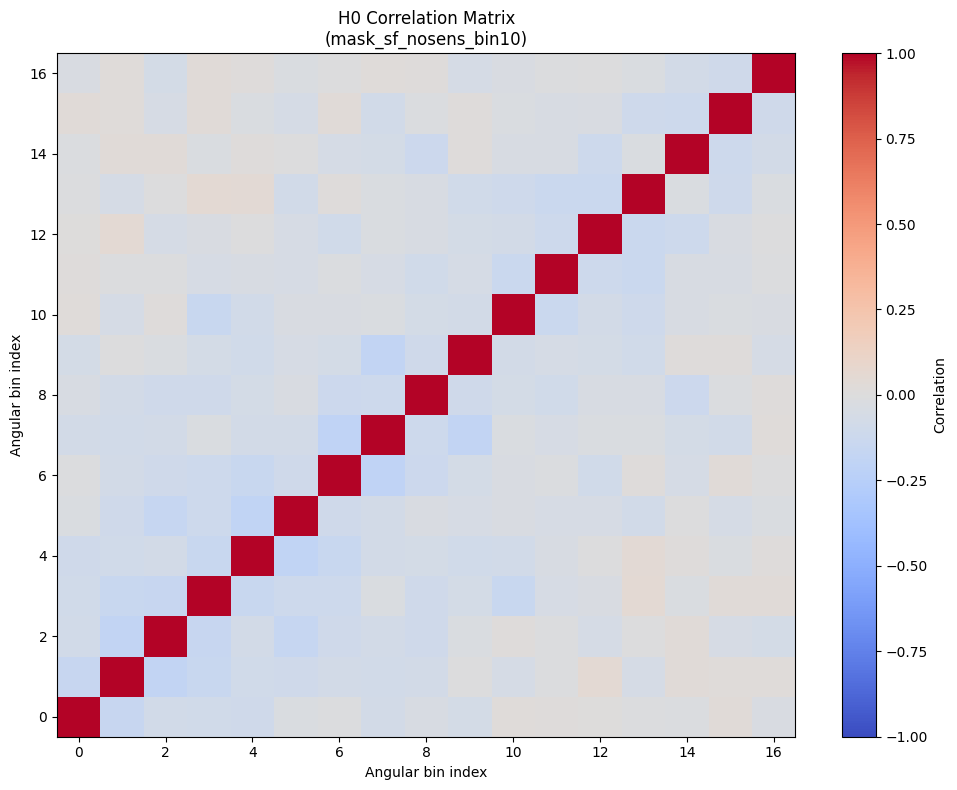


Saved correlation matrix:
  H0_correlation_matrix_mask_sf_nosens_bin10.png

MOCK SIMILARITY DIAGNOSTICS
Mocks analyzed: 100
Mean off-diagonal corr: -0.0091
Median off-diagonal corr: -0.0138
95th percentile corr: 0.4113
99th percentile corr: 0.5581
Max off-diagonal corr: 0.7734

Interpretation:
  ⚠ Strong mock correlations detected.
  Covariance estimation may be biased.


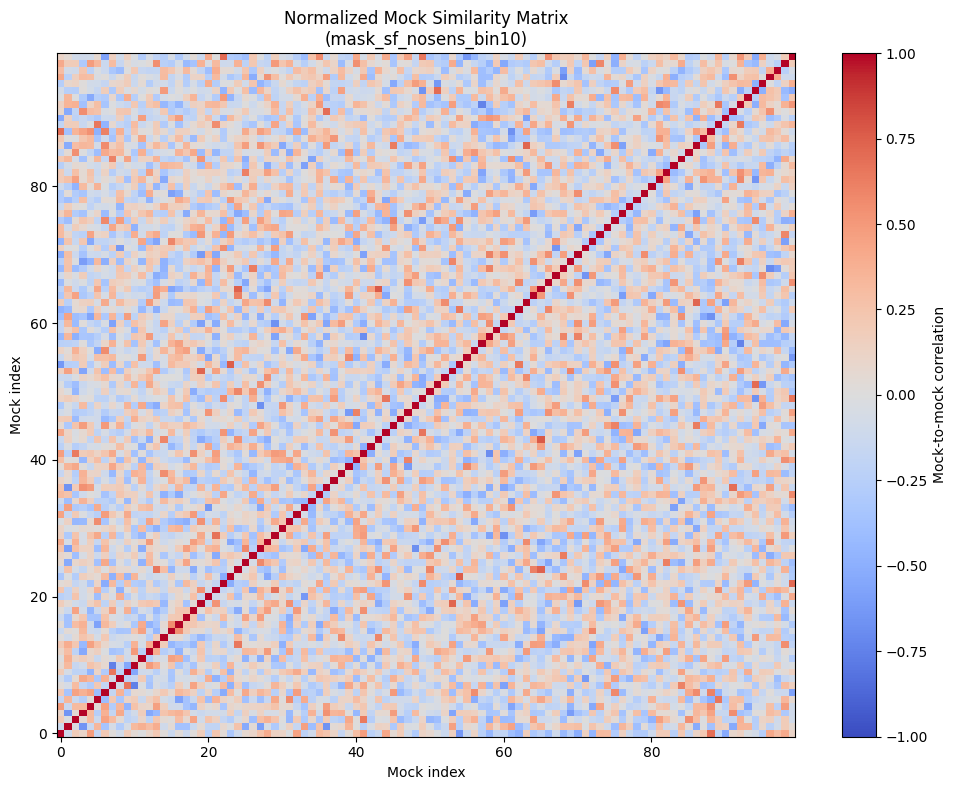


Saved mock similarity matrix:
  H0_mock_similarity_mask_sf_nosens_bin10.png


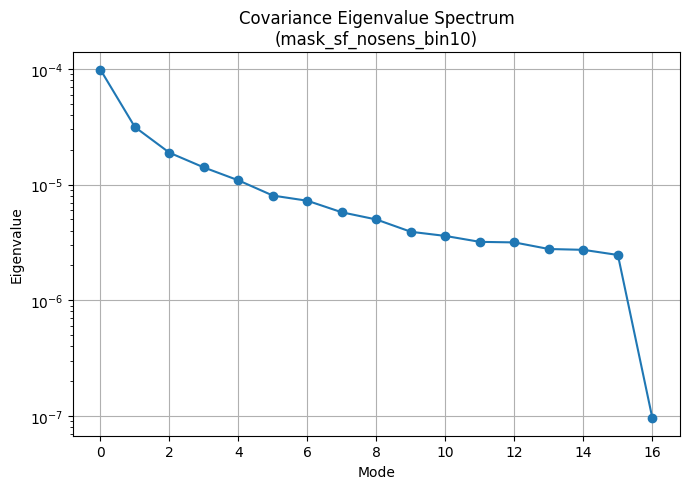


Effective number of modes = 4.23

--- SVD covariance regularization ---
Modes kept: 16/17
Eigenvalue threshold: 1.00e-02
Explained variance kept: 99.96%
SVD condition number: 4.01e+01

--- KS / AD profile tests ---
KS statistic   = 0.47059
KS p-value     = 0.04495
KS empirical p = 0.94306
AD statistic   = 3.45366
AD p-value     = 0.01300
AD empirical p = 0.89411

--- KS / AD profile tests ---
KS statistic   = 0.44444
KS p-value     = 0.35171
KS empirical p = 0.59840
AD statistic   = 0.17445
AD p-value     = 0.25000
AD empirical p = 0.52248

NONPARAMETRIC ISOTROPY DIAGNOSTICS

[w(theta)]
KS p-value          = 0.04495
KS empirical p      = 0.94306
AD p-value          = 0.01300
AD empirical p      = 0.89411

[Absolute sum]
KS p-value          = 0.35171
KS empirical p      = 0.59840
AD p-value          = 0.25000
AD empirical p      = 0.52248

--- Full covariance diagnostic (FRB isotropy (mask_sf_nosens_bin10)) ---
Chi2 = 28.194
Chi2/dof = 1.762
p-value (Chi2 analytic) = 2.9971e-02
p-value

In [9]:
stats = iso.compute_statistics(
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    label=f"FRB isotropy ({iso.RUN_TAG})",
)

## 10. Main visualizations


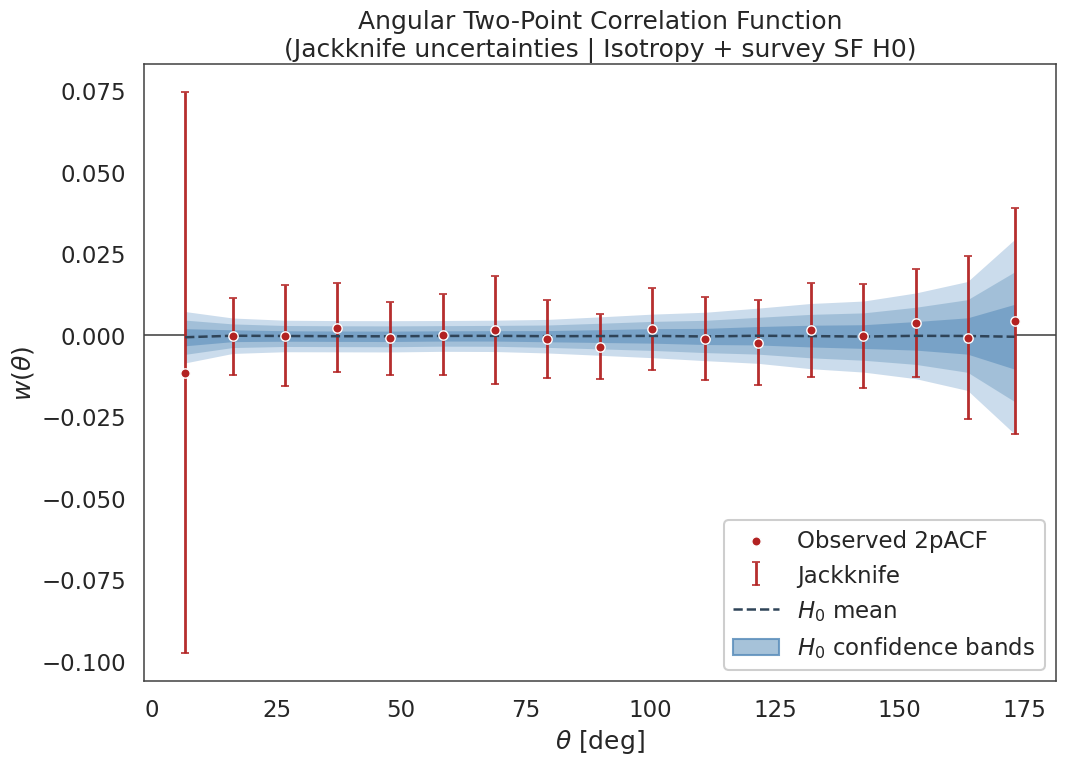

Saved: 2pacf_jackknife_mask_sf_nosens_bin10.png


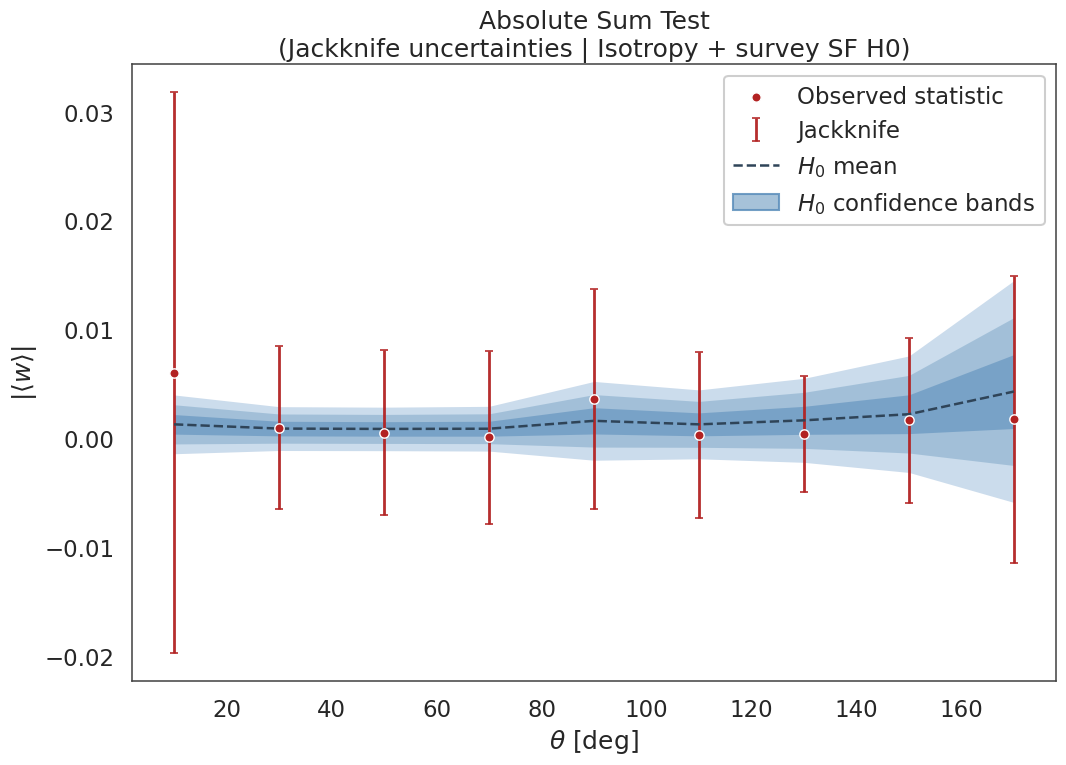

Saved: absolute_anisotropy_jackknife_mask_sf_nosens_bin10.png


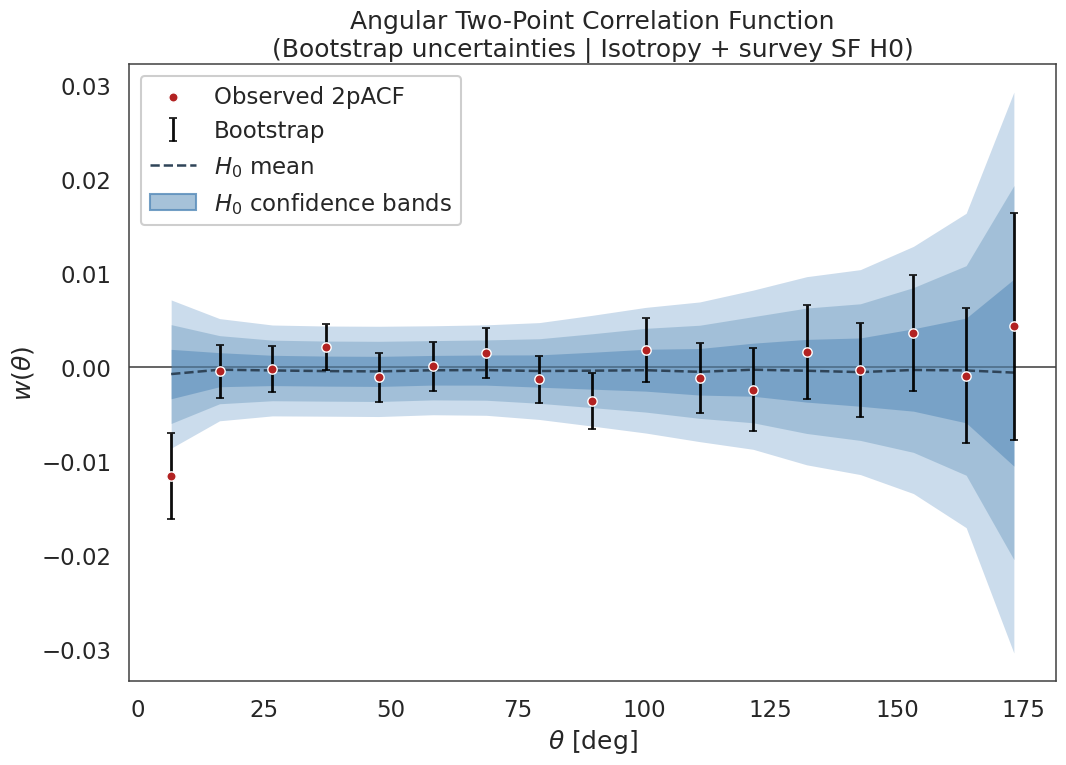

Saved: 2pacf_bootstrap_mask_sf_nosens_bin10.png


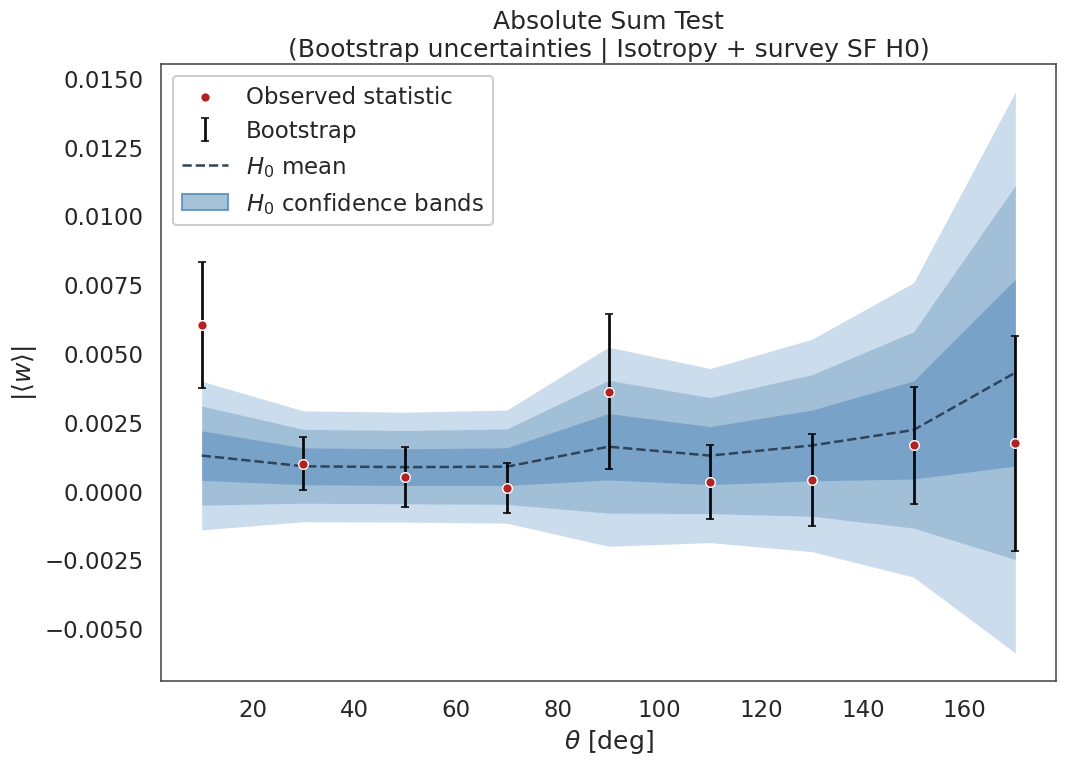

Saved: absolute_anisotropy_bootstrap_mask_sf_nosens_bin10.png


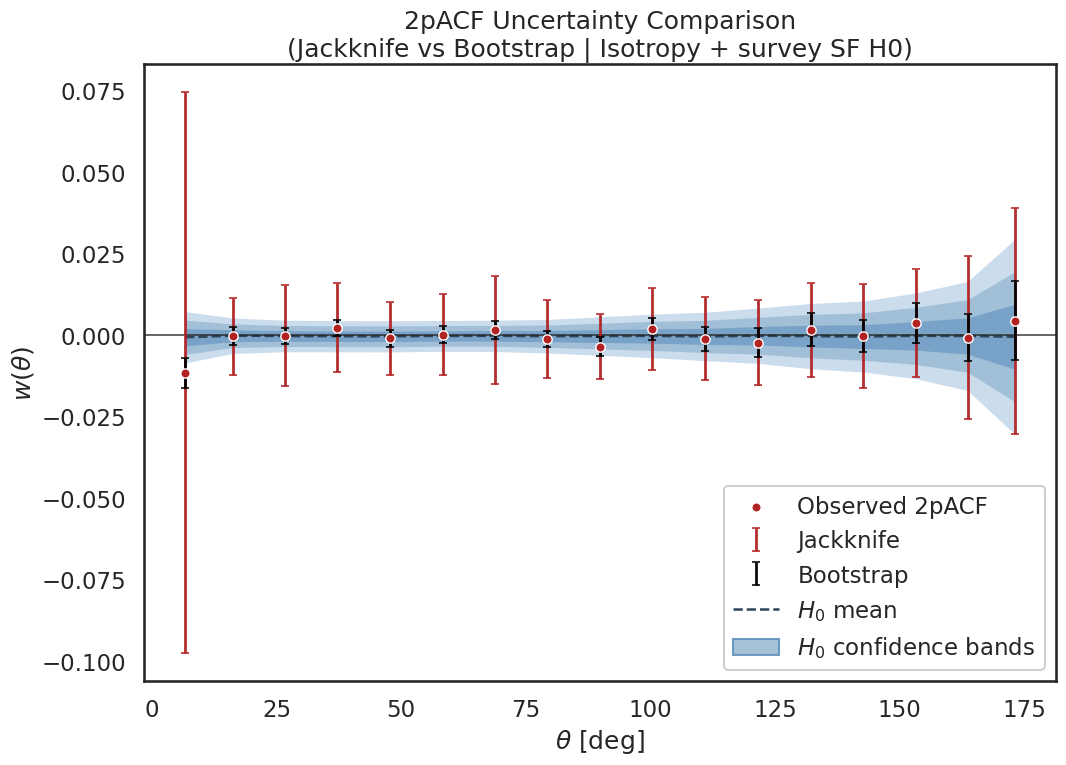

Saved: 2pacf_jk_vs_bootstrap_mask_sf_nosens_bin10.png


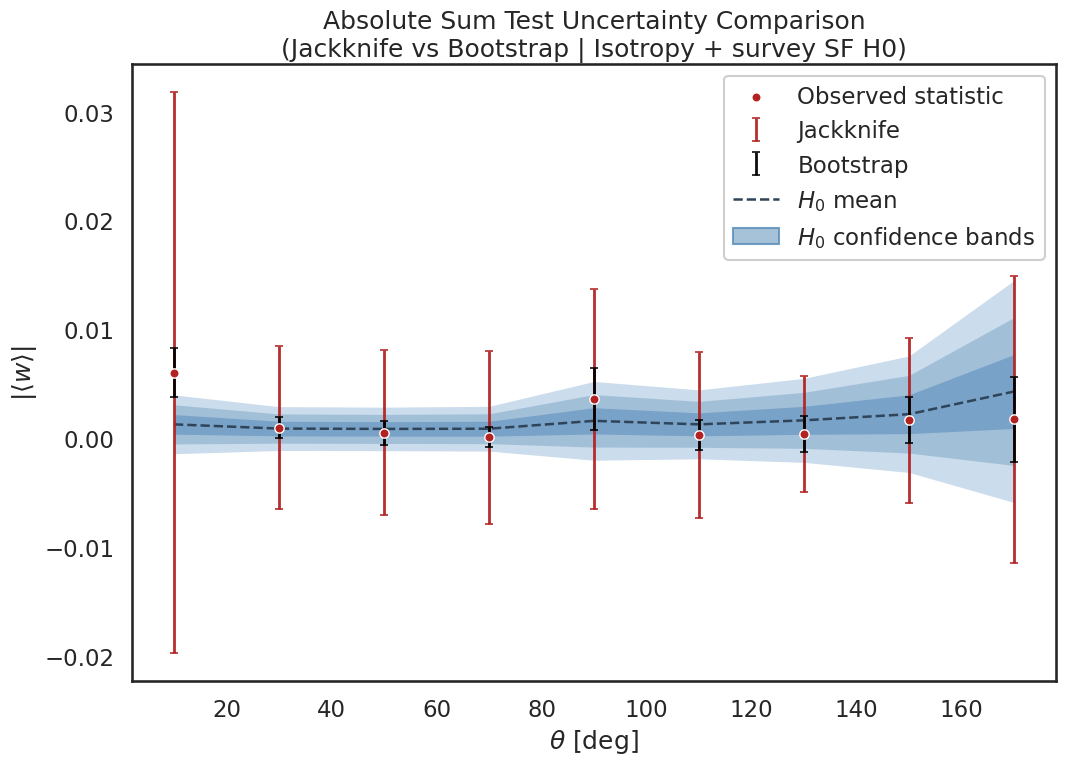

Saved: absolute_anisotropy_jk_vs_bootstrap_mask_sf_nosens_bin10.png


In [10]:
iso.plot_results_with_jackknife(
    theta,
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    jackknife,
)

iso.plot_results_with_bootstrap(
    theta,
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    bootstrap,
)

iso.plot_results_jk_vs_bootstrap(
    theta,
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    jackknife,
    bootstrap,
)

## 11. Optional sensitivity analysis


In [11]:
sensitivity_results = None

if iso.RUN_SENSITIVITY:
    sensitivity_results = iso.run_empirical_sensitivity_analysis(
        df_data,
        n_jobs=iso.N_JOBS,
    )
else:
    print(
        "Sensitivity scan skipped. "
        "Set RUN_SENSITIVITY=True in frb_isotropy.py to run it."
    )

Sensitivity scan skipped. Set RUN_SENSITIVITY=True in frb_isotropy.py to run it.


## 12. Chi-square diagnostics and result assembly


In [12]:
chi2_bin_diagnostics, svd_mode_contributions = (
    iso.compute_chi2_diagnostic_tables(
        theta,
        w_obs,
        all_w_h0,
        eigenvalue_cut=iso.SVD_EIGENVALUE_CUT,
    )
)

results = {
    "config": RUN_CONFIG,
    "df_data": df_data,
    "theta": theta,
    "w_obs": w_obs,
    "abs_obs": abs_obs,
    "sf_dict": sf_dict,
    "sf_cov_diag_dict": sf_cov_diag_dict,
    "survey_weights": survey_weights,
    "sf_validation": sf_validation,
    "survey_map_summary": None,
    "intersurvey_corr": corr_df,
    "intersurvey_overlap": overlap_df,
    "jackknife": jackknife,
    "bootstrap": bootstrap,
    "all_w_h0": all_w_h0,
    "all_abs_h0": all_abs_h0,
    "stats": stats,
    "chi2_bin_diagnostics": chi2_bin_diagnostics,
    "chi2_svd_modes": svd_mode_contributions,
    "covariance_matrix": getattr(iso, "LAST_COVARIANCE_MATRIX", None),
    "sensitivity": sensitivity_results,
}

print("Available result keys:")
print(results.keys())



CHI-SQUARE DIAGNOSTICS

Run tag: mask_sf_nosens_bin10

Mocks: 1000
Bins: 17
Hartlap factor: 0.98198
SVD modes kept: 16 / 17
Eigenvalue cut: 1.000e-02
Covariance condition number: 1.034e+03
Available result keys:
dict_keys(['config', 'df_data', 'theta', 'w_obs', 'abs_obs', 'sf_dict', 'sf_cov_diag_dict', 'survey_weights', 'sf_validation', 'survey_map_summary', 'intersurvey_corr', 'intersurvey_overlap', 'jackknife', 'bootstrap', 'all_w_h0', 'all_abs_h0', 'stats', 'chi2_bin_diagnostics', 'chi2_svd_modes', 'covariance_matrix', 'sensitivity'])


## 13. Save exported tables and report


In [13]:
saved_tables = None

if SAVE_OUTPUTS:
    saved_tables = iso.save_tables(
        results,
        prefix=iso.RUN_TAG,
    )
else:
    print("Output export skipped because SAVE_OUTPUTS=False.")


CHI-SQUARE DIAGNOSTICS

Run tag: mask_sf_nosens_bin10

Mocks: 1000
Bins: 17
Hartlap factor: 0.98198
SVD modes kept: 16 / 17
Eigenvalue cut: 1.000e-02
Covariance condition number: 1.034e+03

--- Saved analysis tables ---
sf_validation: mask_sf_nosens_bin10_sf_validation.csv
intersurvey_corr: mask_sf_nosens_bin10_intersurvey_corr.csv
intersurvey_overlap: mask_sf_nosens_bin10_intersurvey_overlap.csv
stats_summary: mask_sf_nosens_bin10_stats_summary.csv
jackknife_w_errors: mask_sf_nosens_bin10_jackknife_w_errors.csv
jackknife_abs_errors: mask_sf_nosens_bin10_jackknife_abs_errors.csv
covariance_matrix: mask_sf_nosens_bin10_covariance_matrix.csv
chi2_bin_diagnostics: mask_sf_nosens_bin10_chi2_bin_diagnostics.csv
svd_mode_contributions: mask_sf_nosens_bin10_svd_mode_contributions.csv
report: report_mask_sf_nosens_bin10.md


## 14. Useful result summaries


In [14]:
print(stats)

print(
    "Median jackknife sigma w(theta):",
    np.median(jackknife.w_err),
)

print(
    "Median jackknife sigma |<w>|:",
    np.median(jackknife.abs_err),
)

print(
    "Median bootstrap sigma w(theta):",
    np.median(bootstrap.w_err),
)

print(
    "Median bootstrap sigma |<w>|:",
    np.median(bootstrap.abs_err),
)

print("SF validation:")
print(results["sf_validation"])

print("Intersurvey correlation:")
print(results["intersurvey_corr"])

print("Intersurvey overlap:")
print(results["intersurvey_overlap"])

print("Jackknife W covariance shape:")
print(results["jackknife"].w_cov.shape)

print("Jackknife absolute covariance shape:")
print(results["jackknife"].abs_cov.shape)

print("Bootstrap W covariance shape:")
print(results["bootstrap"].w_cov.shape)

print("Bootstrap absolute covariance shape:")
print(results["bootstrap"].abs_cov.shape)

TestStatistics(chi2=28.194239906881936, chi2_red=1.762139994180121, p_chi2=0.02997101715496854, p_empirical=0.052947052947052944, p_empirical_floor=0.000999000999000999, sigma_equiv=1.6169266922322216, chi2_svd=25.258378861124033, chi2_svd_red=1.578648678820252, p_chi2_svd=0.06539807573887772, p_svd_empirical=0.08091908091908091, p_svd_empirical_floor=0.000999000999000999, sigma_svd_equiv=1.3989160405098895, global_tension=1.25734648582797, ks_w_stat=0.47058823529411764, ks_w_pvalue=0.04495293297598427, ks_w_empirical_p=0.9430569430569431, ad_w_stat=3.4536631805923976, ad_w_pvalue=0.013000308327715086, ad_w_empirical_p=0.8941058941058941, ks_abs_stat=0.4444444444444444, ks_abs_pvalue=0.35170711641299873, ks_abs_empirical_p=0.5984015984015985, ad_abs_stat=0.17445345778522048, ad_abs_pvalue=0.25, ad_abs_empirical_p=0.5224775224775224, abs_observed_stat=0.002503801785289923, abs_empirical_p=0.3306693306693307, hartlap_factor=0.9819819819819819, covariance_rank=17, covariance_condition=103

## 15. Optional survey footprint maps


In [15]:
if RUN_TOP_SURVEY_MAPS and iso.USE_SEL_FUNC:
    survey_map_summary = iso.plot_top_survey_maps(
        df_data,
        sf_dict,
        survey_weights,
        sf_nside,
        max_surveys=12,
        output_prefix=f"survey_maps_{iso.RUN_TAG}",
    )

    results["survey_map_summary"] = survey_map_summary
else:
    print(
        "Top survey maps skipped. "
        "Set RUN_TOP_SURVEY_MAPS=True to generate them."
    )

Top survey maps skipped. Set RUN_TOP_SURVEY_MAPS=True to generate them.
